In [1]:
# ===========================
# IMPORT LIBRARIES
# ===========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# LOAD EXCEL FILE
# ===========================

df = pd.read_excel("/content/Task05_Sample_Dataset.xlsx")

# ===========================
# SHOW FIRST ROWS
# ===========================

print("First 5 Rows")
display(df.head())

# ===========================
# DATA INFORMATION
# ===========================

print("\nDataset Information")
df.info()

# ===========================
# DATA SHAPE
# ===========================

print("\nRows and Columns")
print(df.shape)

# ===========================
# COLUMN NAMES
# ===========================

print("\nColumn Names")
print(df.columns)

# ===========================
# MISSING VALUES
# ===========================

print("\nMissing Values")
print(df.isnull().sum())

# ===========================
# DUPLICATES
# ===========================

print("\nDuplicate Records")
print(df.duplicated().sum())

# ===========================
# SUMMARY STATISTICS
# ===========================

print("\nSummary Statistics")
display(df.describe(include='all'))

First 5 Rows


,Company_ID,Company_Name,Job_ID,Job_Title,Job_Post_Date,Student_ID,Student_Name,Skills_Match,Applied_Date,Application_Status,Shortlisted,Interview_Status,Final_Status,Location
0,C003,CloudNest,J1002,SQL Analyst,2026-06-04,S2002,Student_1,64,2026-06-10,Applied,No,Pending,In Progress,Bengaluru
1,C003,TechNova,J1003,BI Analyst,2026-06-26,S2003,Student_2,71,2026-07-03,Shortlisted,Yes,Scheduled,In Progress,Noida
2,C001,CodeWorks,J1004,BI Analyst,2026-06-05,S2004,Student_3,92,2026-06-11,Rejected,No,Pending,In Progress,Hyderabad
3,C005,CloudNest,J1005,Data Analyst,2026-06-10,S2005,Student_4,98,2026-06-16,Rejected,No,Pending,In Progress,Delhi
4,C003,CloudNest,J1006,BI Analyst,2026-06-04,S2006,Student_5,95,2026-06-07,Shortlisted,Yes,Scheduled,Selected,Bengaluru



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Company_ID          200 non-null    object
 1   Company_Name        200 non-null    object
 2   Job_ID              200 non-null    object
 3   Job_Title           200 non-null    object
 4   Job_Post_Date       200 non-null    object
 5   Student_ID          200 non-null    object
 6   Student_Name        200 non-null    object
 7   Skills_Match        200 non-null    int64 
 8   Applied_Date        200 non-null    object
 9   Application_Status  200 non-null    object
 10  Shortlisted         200 non-null    object
 11  Interview_Status    200 non-null    object
 12  Final_Status        200 non-null    object
 13  Location            200 non-null    object
dtypes: int64(1), object(13)
memory usage: 22.0+ KB

Rows and Columns
(200, 14)

Column Names
Index(['Comp

,Company_ID,Company_Name,Job_ID,Job_Title,Job_Post_Date,Student_ID,Student_Name,Skills_Match,Applied_Date,Application_Status,Shortlisted,Interview_Status,Final_Status,Location
count,200,200,200,200,200,200,200,200.000000,200,200,200,200,200,200
unique,5,5,200,4,31,200,200,NaN,38,4,2,2,2,5
top,C005,TechNova,J1002,Data Analyst,2026-06-09,S2002,Student_1,NaN,2026-07-01,Shortlisted,No,Pending,In Progress,Noida
freq,43,48,1,55,12,1,1,NaN,12,55,145,145,171,50
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.710000,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.043155,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# ==========================================
# BLOCK 2 : DATA CLEANING + KPI METRICS
# ==========================================

# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing values (if any)
df = df.dropna()

# Convert date columns to datetime format
df["Job_Post_Date"] = pd.to_datetime(df["Job_Post_Date"])
df["Applied_Date"] = pd.to_datetime(df["Applied_Date"])

print("Data Cleaning Completed Successfully!")

# ==========================================
# KPI METRICS
# ==========================================

total_companies = df["Company_ID"].nunique()
total_jobs = df["Job_ID"].nunique()
total_students = df["Student_ID"].nunique()
total_applications = len(df)

shortlisted = (df["Shortlisted"] == "Yes").sum()

selected = (df["Final_Status"] == "Selected").sum()

shortlist_rate = (shortlisted / total_applications) * 100
selection_rate = (selected / total_applications) * 100

# ==========================================
# DISPLAY KPIs
# ==========================================

print("\n========== LIQUIDITY DASHBOARD KPIs ==========\n")

print(f"Total Companies      : {total_companies}")
print(f"Total Jobs Posted    : {total_jobs}")
print(f"Total Students       : {total_students}")
print(f"Total Applications   : {total_applications}")
print(f"Shortlisted          : {shortlisted}")
print(f"Final Selected       : {selected}")
print(f"Shortlist Rate       : {shortlist_rate:.2f}%")
print(f"Selection Rate       : {selection_rate:.2f}%")

# ==========================================
# COMPANY-WISE JOB COUNT
# ==========================================

company_jobs = (
    df.groupby("Company_Name")["Job_ID"]
      .count()
      .sort_values(ascending=False)
)

print("\nCompany-wise Job Count")
display(company_jobs)

# ==========================================
# LOCATION-WISE APPLICATION COUNT
# ==========================================

location_applications = (
    df.groupby("Location")["Student_ID"]
      .count()
      .sort_values(ascending=False)
)

print("\nLocation-wise Applications")
display(location_applications)

Data Cleaning Completed Successfully!

========== LIQUIDITY DASHBOARD KPIs ==========

Total Companies      : 5
Total Jobs Posted    : 200
Total Students       : 200
Total Applications   : 200
Shortlisted          : 55
Final Selected       : 29
Shortlist Rate       : 27.50%
Selection Rate       : 14.50%

Company-wise Job Count


,Job_ID
Company_Name,
TechNova,48
CloudNest,41
AI Labs,39
CodeWorks,39
DataSphere,33



Location-wise Applications


,Student_ID
Location,
Noida,50
Pune,41
Hyderabad,39
Delhi,37
Bengaluru,33


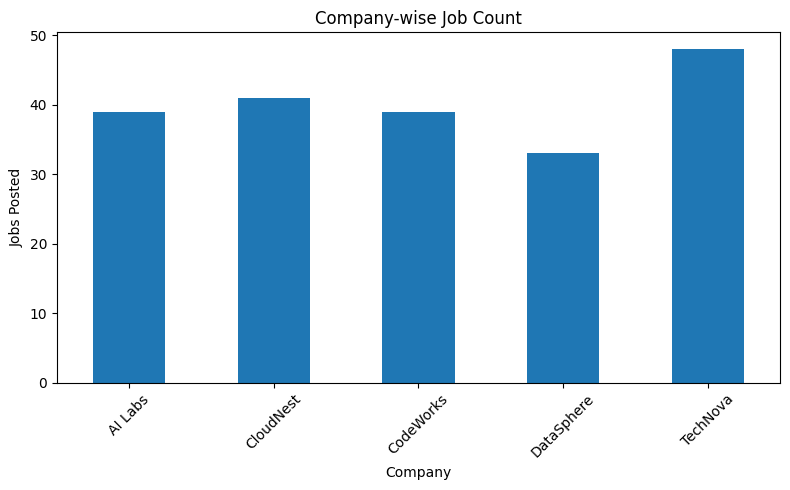

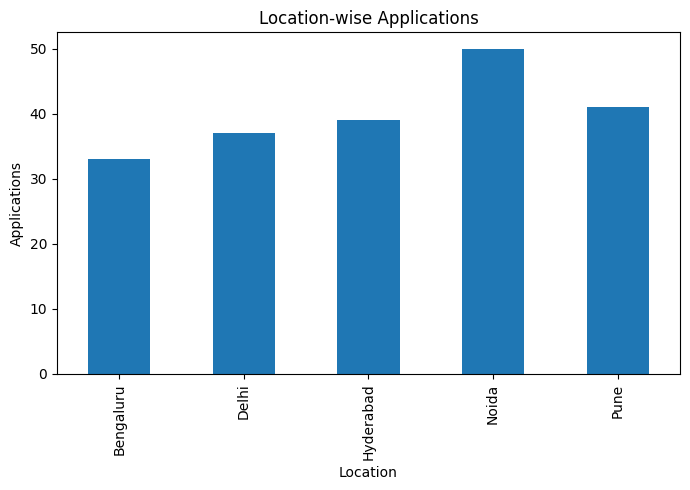

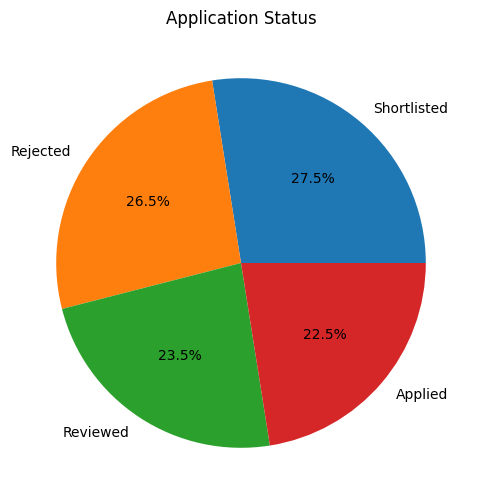

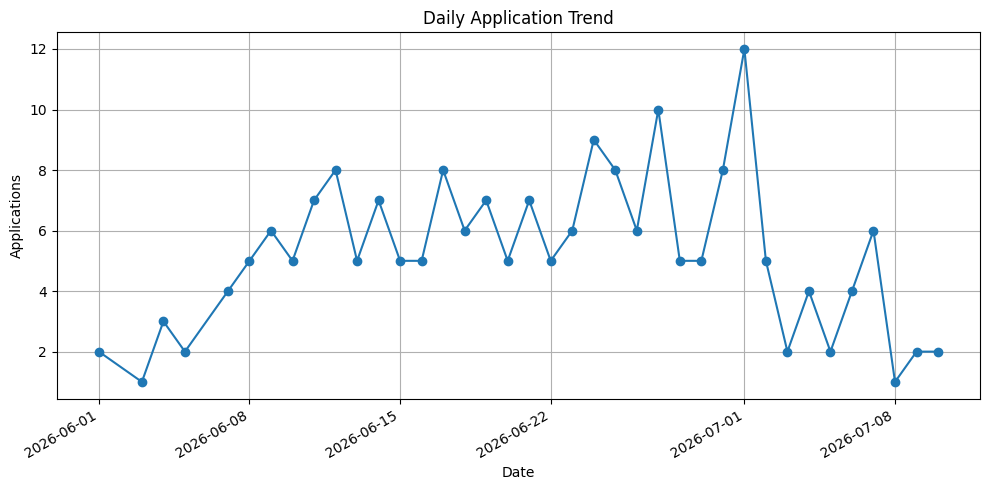

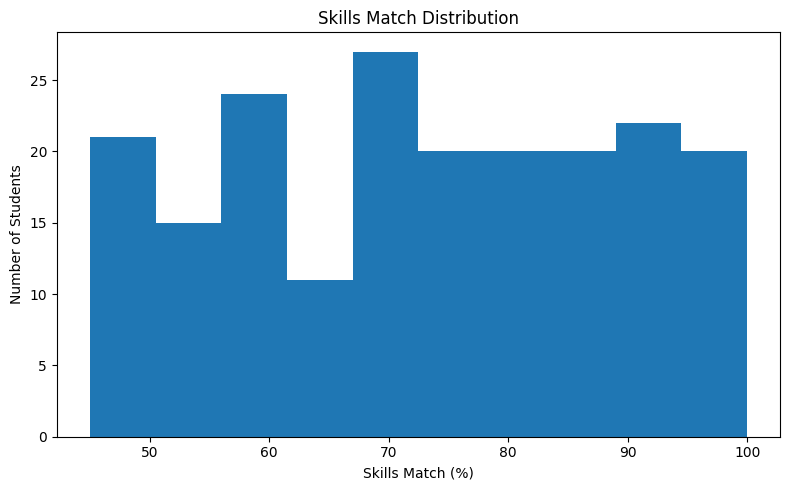

In [3]:
# ==========================================
# BLOCK 3 : PROFESSIONAL CHARTS
# ==========================================

import matplotlib.pyplot as plt

# 1. Company-wise Job Count
company_jobs = df.groupby("Company_Name")["Job_ID"].count()

plt.figure(figsize=(8,5))
company_jobs.plot(kind="bar")
plt.title("Company-wise Job Count")
plt.xlabel("Company")
plt.ylabel("Jobs Posted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Location-wise Applications
location_apps = df.groupby("Location")["Student_ID"].count()

plt.figure(figsize=(7,5))
location_apps.plot(kind="bar")
plt.title("Location-wise Applications")
plt.xlabel("Location")
plt.ylabel("Applications")
plt.tight_layout()
plt.show()


# 3. Application Status
status = df["Application_Status"].value_counts()

plt.figure(figsize=(6,6))
status.plot(kind="pie", autopct="%1.1f%%")
plt.title("Application Status")
plt.ylabel("")
plt.show()


# 4. Daily Applications Trend
daily = df.groupby("Applied_Date")["Student_ID"].count()

plt.figure(figsize=(10,5))
daily.plot(kind="line", marker="o")
plt.title("Daily Application Trend")
plt.xlabel("Date")
plt.ylabel("Applications")
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Skills Match Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Skills_Match"], bins=10)
plt.title("Skills Match Distribution")
plt.xlabel("Skills Match (%)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# BLOCK 4 : FINAL DASHBOARD SUMMARY
# ==========================================

print("="*50)
print("      LIQUIDITY DASHBOARD REPORT")
print("="*50)

print(f"Total Companies       : {total_companies}")
print(f"Total Jobs            : {total_jobs}")
print(f"Total Students        : {total_students}")
print(f"Total Applications    : {total_applications}")
print(f"Shortlisted           : {shortlisted}")
print(f"Selected              : {selected}")
print(f"Shortlist Rate        : {shortlist_rate:.2f}%")
print(f"Selection Rate        : {selection_rate:.2f}%")

print("="*50)

print("\nTop 5 Companies by Jobs Posted")
print(company_jobs.sort_values(ascending=False).head())

print("\nTop Locations by Applications")
print(location_apps.sort_values(ascending=False))

print("\nApplication Status")
print(df["Application_Status"].value_counts())

print("\nDashboard Completed Successfully!")
print("="*50)

      LIQUIDITY DASHBOARD REPORT
Total Companies       : 5
Total Jobs            : 200
Total Students        : 200
Total Applications    : 200
Shortlisted           : 55
Selected              : 29
Shortlist Rate        : 27.50%
Selection Rate        : 14.50%

Top 5 Companies by Jobs Posted
Company_Name
TechNova      48
CloudNest     41
AI Labs       39
CodeWorks     39
DataSphere    33
Name: Job_ID, dtype: int64

Top Locations by Applications
Location
Noida        50
Pune         41
Hyderabad    39
Delhi        37
Bengaluru    33
Name: Student_ID, dtype: int64

Application Status
Application_Status
Shortlisted    55
Rejected       53
Reviewed       47
Applied        45
Name: count, dtype: int64

Dashboard Completed Successfully!
